# YouTube Trending Analysis — 02 Analysis

How do views, likes, and comments relate on trending videos, and what does audience sentiment look like?

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
df=utils.load_data()
print('snapshots',len(df),'unique videos',df.ytvideoid.nunique())

snapshots 200000 unique videos 11160


## 1. Engagement distributions (log scale)

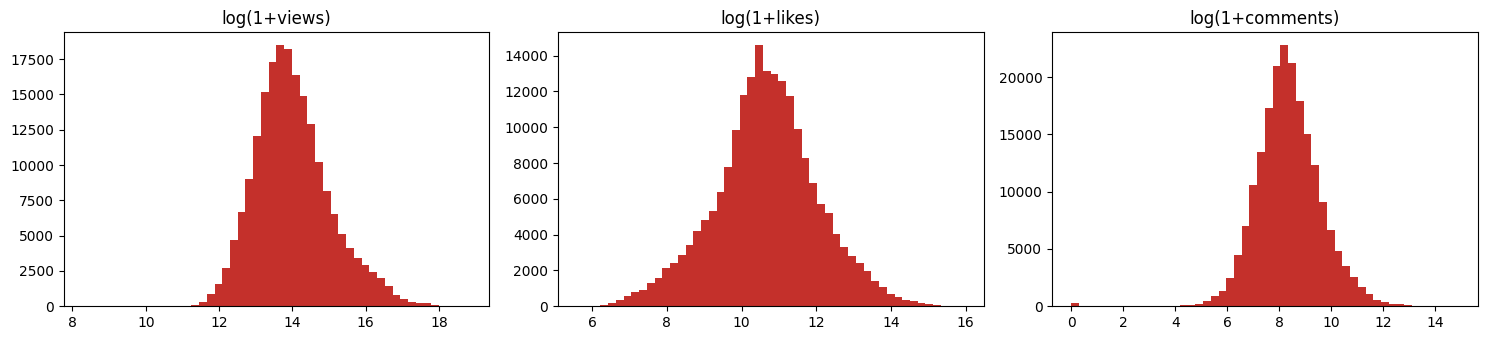

             views      likes   dislikes   comments
count     200000.0   200000.0   200000.0   200000.0
mean     2330972.0   113755.0     4498.0    10658.0
std      4743308.0   283033.0    72758.0    49489.0
min         3969.0      270.0        6.0        0.0
25%       604400.0    19034.0      471.0     1993.0
50%      1091419.0    42757.0     1024.0     4036.0
75%      2174954.0    99438.0     2513.0     8888.0
max    152598177.0  8516294.0  7026319.0  2918955.0


In [2]:
fig,ax=plt.subplots(1,3,figsize=(15,3.5))
for a,c in zip(ax,['views','likes','comments']): a.hist(np.log1p(df[c]),bins=50,color='#c4302b'); a.set_title(f'log(1+{c})')
plt.tight_layout(); plt.show()
print(df[['views','likes','dislikes','comments']].describe().round(0).to_string())

## 2. Views vs likes / comments — engagement scales together

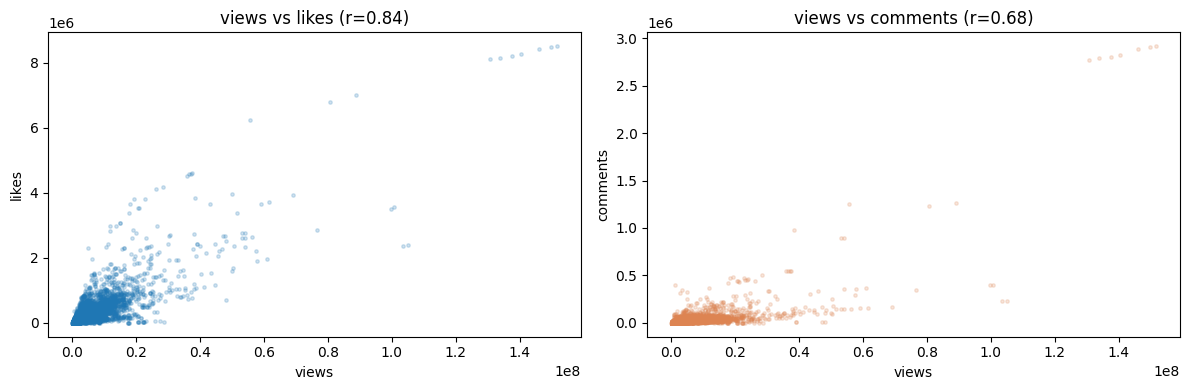

In [3]:
s=df.sample(min(20000,len(df)),random_state=42)
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].scatter(s.views,s.likes,alpha=0.2,s=6); ax[0].set_xlabel('views'); ax[0].set_ylabel('likes'); ax[0].set_title(f'views vs likes (r={df.views.corr(df.likes):.2f})')
ax[1].scatter(s.views,s.comments,alpha=0.2,s=6,color='#dd8452'); ax[1].set_xlabel('views'); ax[1].set_ylabel('comments'); ax[1].set_title(f'views vs comments (r={df.views.corr(df.comments):.2f})')
plt.tight_layout(); plt.show()

## 3. Audience sentiment — like ratio

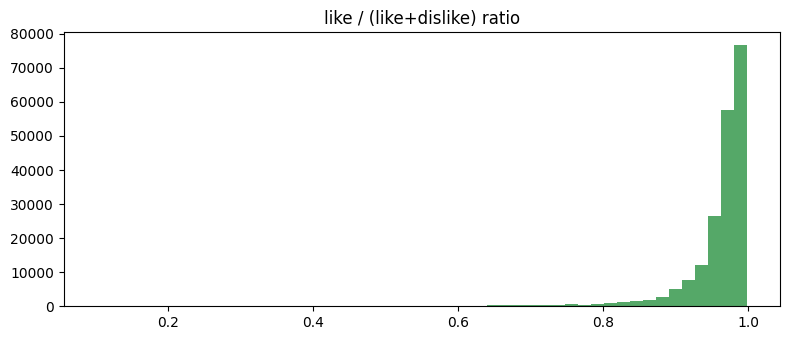

median like ratio: 0.976


In [4]:
df['like_ratio']=df['likes']/(df['likes']+df['dislikes']+1)
fig,ax=plt.subplots(figsize=(8,3.5)); ax.hist(df['like_ratio'],bins=50,color='#55a868'); ax.set_title('like / (like+dislike) ratio'); plt.tight_layout(); plt.show()
print('median like ratio: %.3f'%df['like_ratio'].median())

## 4. Correlation heatmap

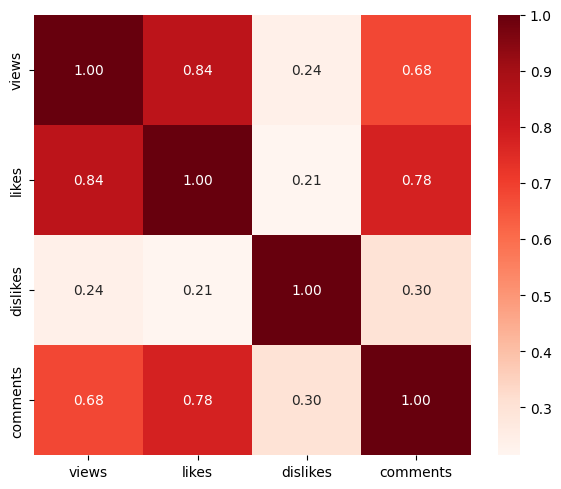

In [5]:
fig,ax=plt.subplots(figsize=(6,5)); sns.heatmap(df[['views','likes','dislikes','comments']].corr(),annot=True,fmt='.2f',cmap='Reds',ax=ax); plt.tight_layout(); plt.show()

## 5. Key findings

- **200,000 stat snapshots across ~11,160 trending videos** (mean ~2.3M views, ~114k likes per snapshot).
- **Engagement scales together** — views correlate **0.84** with likes and **0.68** with comments: a trending video that gets views gets proportional likes/comments.
- **Trending audiences are overwhelmingly positive** — the median like ratio is **0.976** (dislikes are rare on trending content).
- All engagement metrics are heavily right-skewed (a few mega-viral videos dominate) — hence the log scales.
- Note: this dataset is stat snapshots (views/likes/comments over time), not title/category metadata, so the analysis focuses on engagement dynamics.